# Задание 10 (Контрольные вопросы)
## Тема: Проверка статистических гипотез. Непараметрические критерии

### Настройка окружения

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

### 1. Формулировка центральной предельной теоремы. Применение.

***Центральная предельная теорема (ЦПТ):*** для любой генеральной совокупности со средним $\mu$ и среднеквадратичным отклонением $\sigma$ распределение выборочных средних выборок размера $n$ будет иметь среднее $\mu$ и среднеквадратичное отклонение $\frac{\sigma}{\sqrt{n}}$, а его форма будет стремиться к нормальной при $n$ стремящемся к бесконечности.

***Основное применение ЦПТ*** - статистические оценки. Приблизительное распределение выборочного среднего позволяет строить доверительные интервалы и проводить гипотезы о среднем значении генеральной совокупности, даже если сама совокупность не имеет нормального распределения.

### 2. Задание
С помощью функции `stats.expon()` из модуля `scipy.stats` задать экспоненциальное распределение с параметром $scale=5$. С помощью метода `rvs()` для заданного распределения по 1000 раз смоделировать выборки объема: 10, 50, 100, 1000 элементов. Построить гистограмму средних для каждого объема выборки. Посчитать выборочные среднее, стандартное отклонение и коэффициент вариации для каждого объема выборки. Сделать соответствующие выводы.

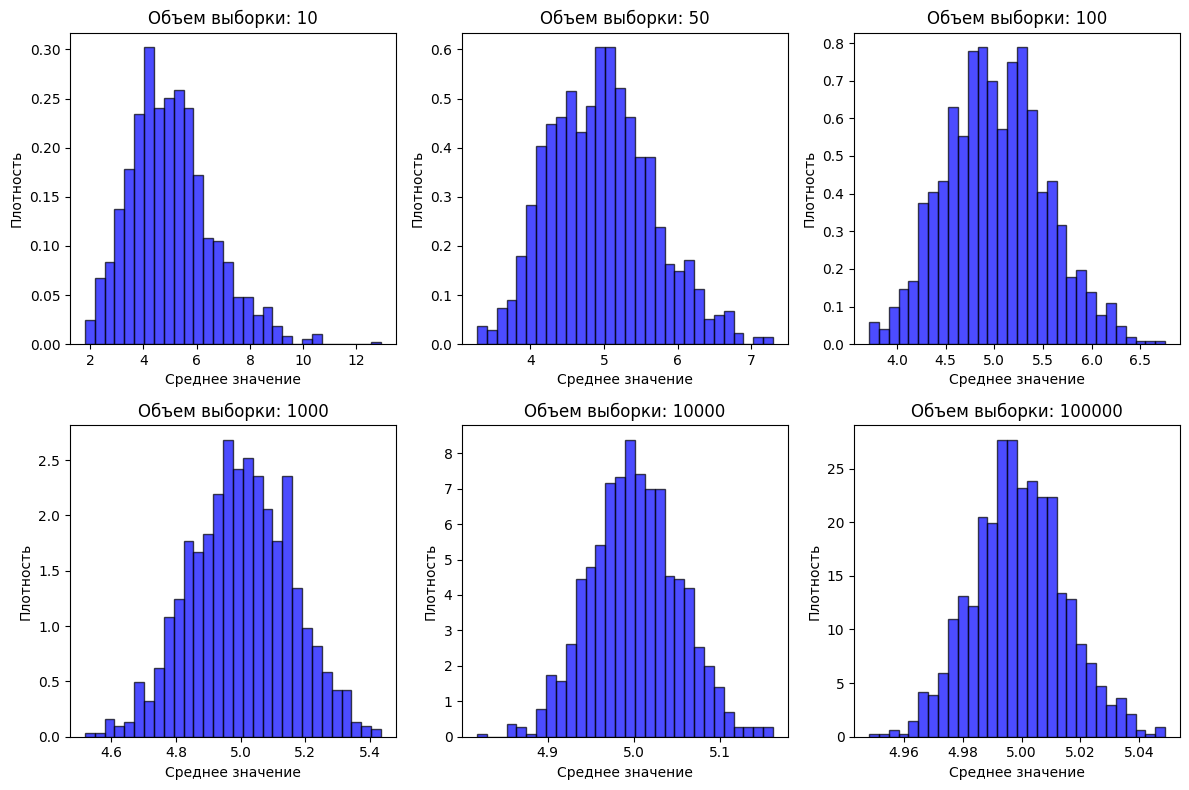

|   Объем выборки (n) |   Среднее (Mean) |   Ст. отклонение (Std) |   Коэф. вариации (CV), % |
|---------------------|------------------|------------------------|--------------------------|
|                  10 |             5.03 |                   1.56 |                    30.94 |
|                  50 |             4.96 |                   0.7  |                    14.05 |
|                 100 |             5.01 |                   0.52 |                    10.28 |
|                1000 |             5    |                   0.15 |                     3.09 |
|               10000 |             5    |                   0.05 |                     1.03 |
|              100000 |             5    |                   0.02 |                     0.31 |


In [50]:
from tabulate import tabulate

scale_param = 5

sample_sizes = [10, 50, 100, 1000, 10_000, 100_000]
num_simulations = 1000


sample_means = {size: [] for size in sample_sizes}


for size in sample_sizes:
    for _ in range(num_simulations):
        sample = stats.expon(scale=scale_param).rvs(size)
        sample_means[size].append(np.mean(sample))


fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, size in enumerate(sample_sizes):
    axes[i].hist(
        sample_means[size],
        bins=30,
        alpha=0.7,
        color="b",
        edgecolor="black",
        density=True,
    )
    axes[i].set_title(f"Объем выборки: {size}")
    axes[i].set_xlabel("Среднее значение")
    axes[i].set_ylabel("Плотность")

plt.tight_layout()
plt.show()

table_data = []

for size in sample_sizes:
    means = np.array(sample_means[size])
    mean_value = np.mean(means)
    std_dev = np.std(means, ddof=1)
    coef_variation = (std_dev / mean_value) * 100

    table_data.append(
        [size, round(mean_value, 2), round(std_dev, 2), round(coef_variation, 2)]
    )

print(tabulate(
    table_data,
    headers=["Объем выборки (n)", "Среднее (Mean)", "Ст. отклонение (Std)", "Коэф. вариации (CV), %"],
    tablefmt="github"
))

### 3. Что такое гипотеза? Этапы тестирования гипотезы.

***Гипотеза*** – предположение, которое не противоречит данным и для которого неизвестно, верно оно или нет.

*Этапы тестирования гипотезы:*

- выдвижение гипотезы;
- определение критериев проверки гипотезы;
- сбор данных и подсчет статистик;
- подтверждение или опровержение.

### 4. Нулевая и альтернативная гипотезы. Приведите примеры.

Формулировка ***нулевой гипотезы*** всегда предполагает отсутствие разницы или отсутствие изменений. Ее обозначают как $H_0$ — гипотеза «нулевого эффекта».

***Альтернативная гипотеза*** — это гипотеза о наличии эффекта. Она может быть направленная и ненаправленная — мы можем здесь говорить как и о конкретном изменении в определенную сторону, так и просто выдвигать гипотезу, что изменения есть и они отличны от 0.

*Примеры:*

- проверяем, снижает ли новое лекарство давление лучше, чем старое. $H_0$: Среднее давление не изменилось. $H_1$: Среднее давление уменьшилось. (левосторонняя);
- исследуем, изменилась ли доля дефектных деталей после модернизации оборудования. $H_0$: Доля брака не изменилась. $H_1$: Доля брака изменилась (двусторонняя гипотеза);
- проверяем, влияет ли специальный курс подготовки на средний балл экзамена. $H_0$: Средний балл не изменился после курса. $H_1$: Средний балл увеличился после курса (правосторонняя гипотеза).

### 5. Что такое уровень статистической значимости $\alpha$? Понятие и виды критических областей.

***Уровень статистической значимости $\alpha$*** — вероятность получить очень маловероятную выборку (максимально отличную по своим характеристикам от генеральной совокупности). Уровень статистической значимости определяет границы ***критической области*** — области распределения, содержащей такие маловероятные выборки. Если статистика выборки (например, среднее) попадает в критическую область — нулевая гипотеза отвергается.

Критическая область бывает односторонней (левосторонней и правосторонней) и двусторонней.

### 6. Типы ошибок при тестировании гипотез. Приведите практические примеры ошибок.

При тестировании гипотез выделяют два вида ошибок — ошибки 1-го или 2-го рода или типа.

|                        | **Нет эффекта в реальности**, $H_0$ верна | **Есть эффект в реальности**, $H_0$ не верна |
|------------------------|--------------------------------------------|------------------------------------------------|
| **Отвергаем $H_0$**       | Ошибка 1-го типа                           | Верное решение                                 |
| **Не отвергаем $H_0$**    | Верное решение                             | Ошибка 2-го типа                               |


***Ошибка первого типа*** связана с тем, что мы отвергаем нулевую гипотезу, когда она на самом деле корректна.

***Ошибка второго типа*** связана с тем, что мы не отвергаем нулевую гипотезу, хотя на самом деле некоторая разница или взаимосвязь существует.

*Примеры ошибок:*

- ошибка первого типа. Медицинский тест на COVID-19 $H_0$: У человека нет COVID-19. $H_1$: У человека есть COVID-19. Здоровому человеку поставили диагноз COVID-19 (ложноположительный результат);
- ошибка второго типа. Медицинский тест на рак $H_0$: У пациента нет рака. $H_1$: У пациента есть рак. Ошибка II рода: Больного человека признали здоровым (ложноотрицательный результат).

### 7. Параметрические и непараметрические критерии проверки статистических гипотез: описание и применение.

Статистические критерии для проверки гипотез делятся на:

- ***Параметрические критерии*** основываются на предположениях о некоторых характеристиках (параметрах) генеральных совокупностей. Также особенность таких критериев — для их расчета нам нужны количественные признаки.
**Применяются, если:** 
    - данные распределены нормально (или близки к нормальному); 
    - выборки достаточно большие (обычно $n>30$);
    - дисперсии выборок примерно одинаковые (если сравниваются две выборки).

- ***Непараметрические критерии*** обычно не нуждаются в предположениях о параметрах генеральной совокупности или форме ее распределения. Также подходят они и для работы с категориальными и номинальными признаками.
**Применяются, если:** 
    - данные неподходят под нормальное распределение;
    - выборка маленькая ($n<30$);
    - данные представлены категориальными переменными (например, "да/нет", "мужчина/женщина").

### 8. Предпосылки использования критерия хи-квадрат для проверки статистических гипотез.

Предпосылки, при которых мы можем использовать критерий хи-квадрат для проверки статистических гипотез:

- наблюдения должны быть независимы (например, каждый объект в наших данных должен присутствовать ровно один раз);
- ожидаемые частоты для каждой из категорий не должны быть меньше 5;
- в целом рекомендуется использовать такой тест для выборок, в которых не меньше 100 наблюдений.

### 9. Критерий согласия хи-квадрат: назначение и свой пример использования с расчётом в *Python*.

С помощью ***критерия согласия хи-квадрат (критерий согласия Пирсона)*** мы на основании выборки проверяем гипотезу о форме или пропорциях распределения генеральной совокупности. 

Этот статистический тест определяет, насколько распределение выборки близко к форме или пропорциями распределения, описанного в нулевой гипотезе.

In [51]:
observed = np.array([50, 60, 40, 47, 53])
expected = np.array([50] * 5)

chi2, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"Chi2={chi2:.2f}, P-value={p_value:.2f}")

Chi2=4.36, P-value=0.36


### 10. Что такое число степеней свободы? Формула расчёта.

***Число степеней свободы*** - это количество значений в итоговом вычислении статистики, способных варьироваться.

*Формула расчета для критерия согласия хи-квадрат:*

$$
df = C - 1
$$

*Формула расчета для критерия независимости хи-квадрат:*

$$
df = (R - 1) \cdot (C - 1)
$$

### 11. Что такое *p-value*?

***P-value*** – это минимальный уровень значимости, на котором нулевая гипотеза может быть отвергнута.

Проще говоря, это шанс, что результат — просто случайность.

### 11. Критерий независимости хи-квадрат: назначение и свой пример использования с расчётом в *Python*.

С помощью ***критерия независимости хи-квадрат (критерий независимости Пирсона)*** мы на основании выборки проверяем наличие зависимости между двумя признаками в генеральной совокупности.

Каждое наблюдение в выборке принадлежит к одной из категорий обоих интересующих нас признаков, что позволяет нам упорядочить данные в виде таблицы сопряженности.

Распределение частот принадлежности к категориям в выборке используется для того, чтобы протестировать гипотезы о распределении частот в генеральной совокупности

In [52]:
data = pd.DataFrame(
    {
        "Пол": ["М"] * 10 + ["Ж"] * 10,
        "Покупка": ["Да"] * 8 + ["Нет"] * 2 + ["Да"] * 4 + ["Нет"] * 6,
    }
)


contingency = pd.crosstab(data["Пол"], data["Покупка"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi2={chi2:.2f}, P-value={p:.2f}")

Chi2=1.88, P-value=0.17


#### Экспорт в html

In [53]:
from os import system

system("jupyter nbconvert --to html task_10.ipynb")

[NbConvertApp] Converting notebook task_10.ipynb to html
[NbConvertApp] Writing 314982 bytes to task_10.html


0